# Explore SPECFEM2D SEG-Y and SU outputs

This notebook is for quick QC of SPECFEM2D-derived shot gathers. It reads:

- SEG-Y files converted from SPECFEM ASCII/SEMV outputs, and
- Seismic Unix (`.su`) files, trying both endian conventions if necessary.

All figures are written under `outdir`, not into the code repository.


## 1. Configuration

Edit the paths in this cell for the machine/session you are using. The important point is that `outdir` is outside the code repository.


In [1]:
from pathlib import Path
import sys
import obspy

# Repository containing segy_tools. This should be the parent directory of the segy_tools/ package.
repo_dir = Path("~/Developer/karstgeo/01_modeling/specfem2d").expanduser()

# Output root: all notebook-generated figures/tables go here, not into the code repo.
outdir = Path(
    "~/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/Seismic/specfem2d/glenn"
).expanduser()

# Example input directories.
segy_dir = Path("~/Sarah_Mod17_SEGY/BXZ").expanduser()
su_dir = Path("~/Downloads").expanduser()

# Survey geometry defaults used only if files lack usable headers.
fallback_receiver_spacing_m = 0.5
fallback_first_receiver_x_m = 0.0
fallback_source_x_m = 150.0
cave_x_extent = {"x_min_m": 145, "x_max_m": 155}

# Figure output directories.
fig_dir = outdir / "figures" / "explore_specfem_output"
segy_fig_dir = fig_dir / "segy_wiggles"
su_fig_dir = fig_dir / "su_wiggles"
for d in [segy_fig_dir, su_fig_dir]:
    d.mkdir(parents=True, exist_ok=True)

print(f"repo_dir = {repo_dir}")
print(f"outdir   = {outdir}")
print(f"segy_dir = {segy_dir}")
print(f"su_dir   = {su_dir}")


repo_dir = /Users/glennthompson/Developer/karstgeo/01_modeling/specfem2d
outdir   = /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/Seismic/specfem2d/glenn
segy_dir = /Users/glennthompson/Sarah_Mod17_SEGY/BXZ
su_dir   = /Users/glennthompson/Downloads


## 2. Import local plotting and I/O tools

Avoid `os.chdir()` in notebooks. Instead, add the repository directory to `sys.path` if the package has not been installed with `pip install -e .`.


In [2]:
if not (repo_dir / "segy_tools").exists():
    raise FileNotFoundError(
        f"Could not find segy_tools/ under repo_dir={repo_dir}. "
        "Set repo_dir to the parent directory of segy_tools/."
    )

if str(repo_dir) not in sys.path:
    sys.path.insert(0, str(repo_dir))

from segy_tools.gather import plot_wiggle_gather_from_stream
from segy_tools.io import read_su_file

print("Imported segy_tools successfully")


Imported segy_tools successfully


## 3. Read and plot one SEG-Y shot gather

This section reads one SEG-Y file and makes a wiggle plot. The fallback geometry is only used if the SEG-Y headers do not contain usable coordinates.


In [3]:
segy_file = segy_dir / "shot_001_BXZ_semv.segy"

if not segy_file.exists():
    raise FileNotFoundError(f"SEG-Y file not found: {segy_file}")

st = obspy.read(
    str(segy_file),
    format="SEGY",
    unpack_trace_headers=True,
)

print(st)


299 Trace(s) in Stream:

Seq. No. in line:    1 | 1969-12-31T23:59:59.000000Z - 1969-12-31T23:59:59.119980Z | 50000.0 Hz, 6000 samples
...
(297 other traces)
...
Seq. No. in line:  299 | 1969-12-31T23:59:59.000000Z - 1969-12-31T23:59:59.119980Z | 50000.0 Hz, 6000 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]


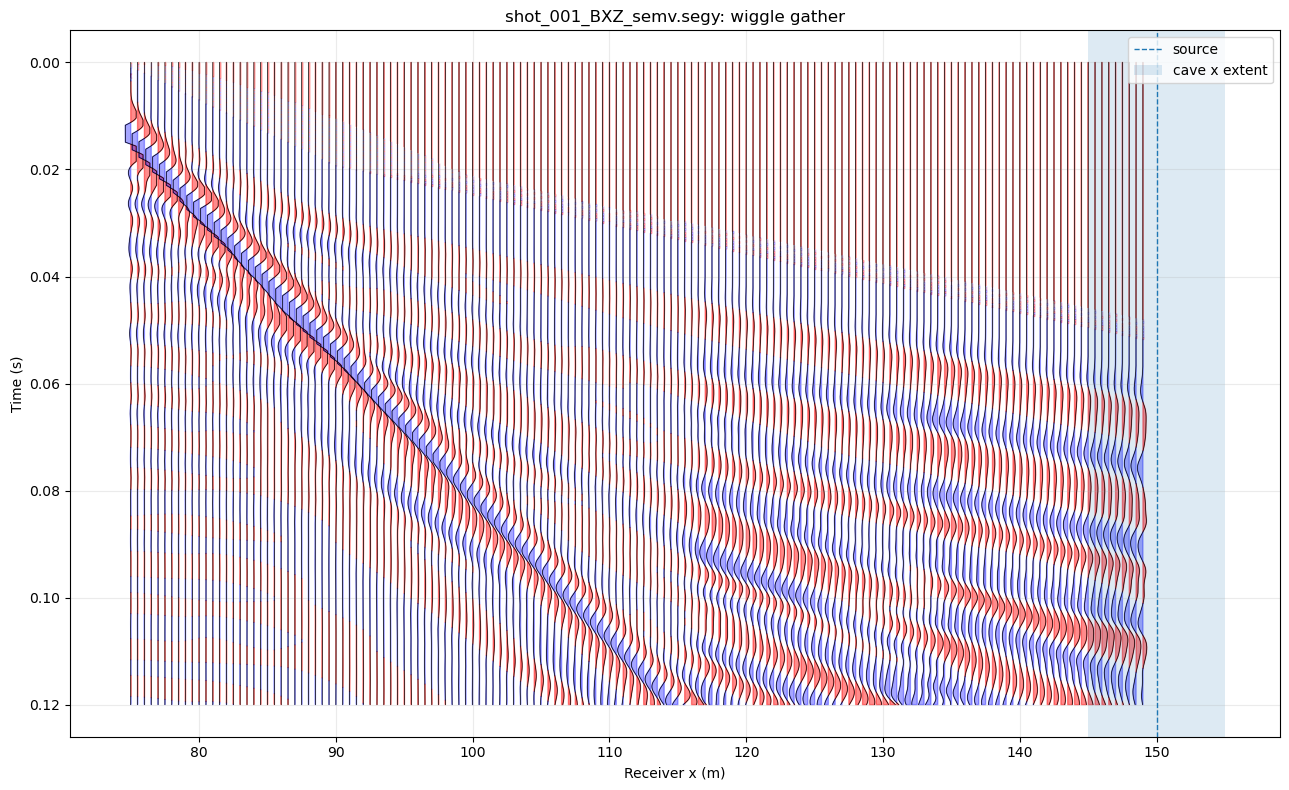

In [4]:
plot_wiggle_gather_from_stream(
    st,
    tmin=0,
    tmax=0.15,
    omin=-75,
    omax=75,
    fallback_receiver_spacing_m=fallback_receiver_spacing_m,
    fallback_first_receiver_x_m=fallback_first_receiver_x_m,
    fallback_source_x_m=fallback_source_x_m,
    cave=cave_x_extent,
    scale=0.8,
    normalize=True,
    title=f"{segy_file.name}: wiggle gather",
    outfile=segy_fig_dir / f"{segy_file.stem}_wiggle.png",
)


In [10]:

from specfem_tools.io import read_sem_gather

from pathlib import Path
import numpy as np


def find_specfem_model_outputs(root):
    root = Path(root).expanduser()
    return sorted(root.glob("Mod*/OUTPUT_FILES"))


def explore_specfem_models(
    root,
    outdir,
    components=("BXX", "BXZ"),
    extension="semv",
    receiver_spacing_m=1.0,
    first_receiver_x_m=0.0,
    tmin=None,
    tmax=None,
    normalize=False,
    scale=0.8,
    timing=None,
    verbose=True,
):
    """
    Find Mod*/OUTPUT_FILES directories and make wiggle plots for each model/component.

    Uses read_sem_gather(input_dir, component=..., extension=...).
    """
    root = Path(root).expanduser()
    outdir = Path(outdir).expanduser()

    figdir = outdir / "figures" / "specfem_model_wiggles"
    figdir.mkdir(parents=True, exist_ok=True)

    model_dirs = find_specfem_model_outputs(root)

    print(f"Found {len(model_dirs)} model output directories")

    for output_dir in model_dirs:
        model_name = output_dir.parent.name
        print(f"\n{model_name}: {output_dir}")

        for component in components:
            try:
                time, data, station_indices = read_sem_gather(
                    output_dir,
                    component=component,
                    extension=extension,
                    timing=timing,
                    verbose=verbose,
                )

                receiver_x_m = (
                    first_receiver_x_m
                    + (station_indices - station_indices.min()) * receiver_spacing_m
                )

                outfile = figdir / f"{model_name}_{component}_wiggle.png"

                plot_wiggle_gather(
                    time=time,
                    data=data,
                    receiver_x_m=receiver_x_m,
                    title=f"{model_name} {component}",
                    tmin=tmin,
                    tmax=tmax,
                    normalize=normalize,
                    scale=scale,
                    outfile=outfile,
                )

                print(f"  wrote {outfile}")

            except Exception as e:
                print(f"  skipped {component}: {type(e).__name__}: {e}")

In [11]:
specfem_root = Path(
    "/Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/"
    "2026KarstGeophysicsDEP/02_Modelling/Seismic/specfem2d"
)

explore_specfem_models(
    root=specfem_root,
    outdir=outdir,
    components=("BXX", "BXZ"),
    extension="semv",
    receiver_spacing_m=1.0,   # change if Sarah used another spacing
    first_receiver_x_m=0.0,
    tmin=0,
    tmax=0.3,
    normalize=False,
    scale=0.8,
)

Found 7 model output directories

Mod10: /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/Seismic/specfem2d/Mod10/OUTPUT_FILES
Found 299 files in /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/Seismic/specfem2d/Mod10/OUTPUT_FILES
  read     1/  299: AA.S0001.BXX.semv
  read    50/  299: AA.S0050.BXX.semv


KeyboardInterrupt: 

In [17]:
from pathlib import Path
import numpy as np
from segy_tools.plotting import plot_wiggle_gather 


def discover_su_files(output_dir):
    return sorted(Path(output_dir).glob("*.su"))


def discover_sem_components(output_dir, extension="semv"):
    files = sorted(Path(output_dir).glob(f"*.{extension}"))
    comps = sorted(set(p.name.split(".")[-2] for p in files))
    return comps


def load_specfem_gather(
    output_dir,
    component="BXZ",
    extension="semv",
    timing=None,
    verbose=True,
):
    """
    Prefer SU if available, otherwise fall back to SPECFEM ASCII.
    """

    output_dir = Path(output_dir)

    su_files = discover_su_files(output_dir)

    # ------------------------------------------------------------
    # Try SU first
    # ------------------------------------------------------------

    if su_files:

        for sufile in su_files:

            try:
                st = None

                for byteorder in ("<", ">"):

                    try:
                        st = read_su_file(
                            sufile,
                            byteorder=byteorder,
                        )

                        if verbose:
                            print(f"Loaded SU: {sufile.name} byteorder={byteorder}")

                        return {
                            "mode": "su",
                            "stream": st,
                            "path": sufile,
                        }

                    except Exception:
                        continue

            except Exception as e:
                if verbose:
                    print(f"Failed SU {sufile.name}: {e}")

    # ------------------------------------------------------------
    # Fallback to ASCII SEMV
    # ------------------------------------------------------------

    if verbose:
        print(f"Falling back to SEM ASCII for {component}")

    time, data, station_indices = read_sem_gather(
        output_dir,
        component=component,
        extension=extension,
        timing=timing,
        verbose=verbose,
    )

    return {
        "mode": "semv",
        "time": time,
        "data": data,
        "station_indices": station_indices,
    }

In [25]:
from pathlib import Path

specfem_root = Path(
    "/Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/"
    "2026KarstGeophysicsDEP/02_Modelling/Seismic/specfem2d"
)

model_output_dirs = sorted(specfem_root.glob("Mod*/OUTPUT_FILES"))

for p in model_output_dirs:
    print(p)
    if p.is_dir():
        print(f"  {p.name} is a directory")
    
        result = load_specfem_gather(
            p,
            component="BXZ",
        )
        outfile = outdir / "figures" / "explore_specfem_output" / f"{p.parent.name}.png"

        if result["mode"] == "su":

            plot_wiggle_gather_from_stream(
                result["stream"],
                normalize=False,
                scale=0.02,
                tmin=0,
                tmax=0.3,
                outfile=outfile,
            )

        else:

            receiver_x_m = (
                result["station_indices"]
                - result["station_indices"].min()
            )

            plot_wiggle_gather(
                time=result["time"],
                data=result["data"],
                receiver_x_m=receiver_x_m,
                normalize=False,
                scale=0.02,
                tmin=0,
                tmax=0.3,
                outfile=outfile,
            )

/Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/Seismic/specfem2d/Mod10/OUTPUT_FILES
  OUTPUT_FILES is a directory
Loaded SU: BXX_velocity.su byteorder=>
/Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/Seismic/specfem2d/Mod12/OUTPUT_FILES
  OUTPUT_FILES is a directory
Falling back to SEM ASCII for BXZ
Found 299 files in /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/Seismic/specfem2d/Mod12/OUTPUT_FILES
  read     1/  299: AA.S0001.BXZ.semv
  read    50/  299: AA.S0050.BXZ.semv
  read   100/  299: AA.S0100.BXZ.semv
  read   150/  299: AA.S0150.BXZ.semv
  read   200/  299: AA.S0200.BXZ.semv
  read   250/  299: AA.S0250.BXZ.semv
  read   299/  299: AA.S0299.BXZ.semv
/Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/Seismic/specfem2d/Mod13/OUTPUT_FILES
  OUTPUT_FILES is a directory
Falling back to SEM 

FileNotFoundError: No SPECFEM ASCII files found in /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/Seismic/specfem2d/Mod13V/OUTPUT_FILES for component=BXZ, extension=semv

## 4. Batch-read SU files and make wiggle plots

ObsPy can read SU files, but byte order can matter. This loop tries little-endian first and big-endian second. Files that fail both are skipped.

The plots preserve relative amplitudes by default here (`normalize=False`), which is useful when checking whether the amplitudes in the SU files are sensible.


In [ ]:
su_files = sorted(su_dir.glob("*_*.su"))
print(f"Found {len(su_files)} SU files")
for f in su_files[:10]:
    print(" ", f.name)


In [ ]:
def read_su_try_both_byteorders(path, dt_s=None, t0_s=0.0):
    """Read an SU file, trying little- and big-endian byte order."""
    last_error = None
    for byteorder in ("<", ">"):
        try:
            st = read_su_file(path, dt_s=dt_s, t0_s=t0_s, byteorder=byteorder)
            return st, byteorder
        except Exception as exc:
            last_error = exc
    raise last_error


In [ ]:
for su_file in su_files:
    print(su_file)

    try:
        st_su, byteorder = read_su_try_both_byteorders(su_file)
        print(f"  read OK with byteorder={byteorder}; {len(st_su)} traces")
    except Exception as exc:
        print(f"  skipping {su_file.name}: {type(exc).__name__}: {exc}")
        continue

    plot_wiggle_gather_from_stream(
        st_su,
        fallback_receiver_spacing_m=2.0,
        fallback_first_receiver_x_m=0.0,
        fallback_source_x_m=0.0,
        tmin=-0.05,
        tmax=0.25,
        scale=0.02,
        normalize=False,
        title=f"{su_file.stem}: SU wiggle gather",
        outfile=su_fig_dir / f"{su_file.stem}_wiggle.png",
    )


## 5. Notes

- Use `normalize=True` for visual trace-by-trace comparison of waveform shape.
- Use `normalize=False` when preserving relative amplitudes matters.
- If SU reading fails for both byte orders, the file may not be true SU, or the trace headers may not match what ObsPy expects.
- All generated figures are under `outdir / figures / explore_specfem_output`.


In [26]:
import numpy as np
from pathlib import Path
from obspy import Stream, Trace, UTCDateTime
from obspy.core import AttribDict

from segy_tools.headers import make_trace_header
from segy_tools.io import write_segy

In [28]:
def specfem_gather_result_to_stream(
    result,
    component="BXZ",
    receiver_spacing_m=1.0,
    first_receiver_x_m=0.0,
    source_x_m=0.0,
    shot_number=1,
    network="SY",
):
    """
    Convert output from load_specfem_gather() to an ObsPy Stream.

    If result came from SU, returns the SU Stream with cleaned/added headers.
    If result came from SEMV, creates a Stream from time/data/station_indices.
    """
    component = component.upper()

    if result["mode"] == "su":
        st = result["stream"].copy()

        # Add/fix basic metadata and SEG-Y headers.
        for i, tr in enumerate(st, start=1):
            receiver_x_m = first_receiver_x_m + (i - 1) * receiver_spacing_m

            tr.stats.network = network
            tr.stats.station = f"S{i:04d}"
            tr.stats.location = f"{shot_number % 100:02d}"
            tr.stats.channel = component

            tr.stats.segy = AttribDict()
            tr.stats.segy.trace_header = make_trace_header(
                station_idx=i,
                receiver_x_m=float(receiver_x_m),
                source_x_m=float(source_x_m),
                shot_number=int(shot_number),
                dt_s=float(tr.stats.delta),
                npts=int(tr.stats.npts),
                receiver_z_m=0.0,
                source_z_m=0.0,
            )

        return st

    if result["mode"] == "semv":
        time = np.asarray(result["time"], dtype=float)
        data = np.asarray(result["data"], dtype=np.float32)
        station_indices = np.asarray(result["station_indices"], dtype=int)

        dt = float(np.median(np.diff(time)))
        st = Stream()

        for i, station_index in enumerate(station_indices):
            receiver_x_m = (
                first_receiver_x_m
                + (station_index - station_indices.min()) * receiver_spacing_m
            )

            tr = Trace(data=data[i].astype(np.float32))
            tr.stats.network = network
            tr.stats.station = f"S{int(station_index):04d}"
            tr.stats.location = f"{shot_number % 100:02d}"
            tr.stats.channel = component
            tr.stats.delta = dt
            tr.stats.starttime = UTCDateTime(1970, 1, 1) + float(time[0])

            tr.stats.segy = AttribDict()
            tr.stats.segy.trace_header = make_trace_header(
                station_idx=int(station_index),
                receiver_x_m=float(receiver_x_m),
                source_x_m=float(source_x_m),
                shot_number=int(shot_number),
                dt_s=dt,
                npts=int(tr.stats.npts),
                receiver_z_m=0.0,
                source_z_m=0.0,
            )

            st.append(tr)

        return st

    raise ValueError(f"Unknown result mode: {result['mode']}")

In [29]:
def save_specfem_gather_as_segy(
    output_dir,
    outfile,
    component="BXZ",
    extension="semv",
    timing=None,
    receiver_spacing_m=1.0,
    first_receiver_x_m=0.0,
    source_x_m=0.0,
    shot_number=None,
    network="SY",
    verbose=True,
):
    """
    Load a SPECFEM gather using load_specfem_gather(), convert to Stream,
    then write SEG-Y.
    """
    output_dir = Path(output_dir)
    outfile = Path(outfile)

    if shot_number is None:
        # Use digits from Mod17 etc. if possible.
        model_name = output_dir.parent.name
        digits = "".join(ch for ch in model_name if ch.isdigit())
        shot_number = int(digits) if digits else 1

    result = load_specfem_gather(
        output_dir,
        component=component,
        extension=extension,
        timing=timing,
        verbose=verbose,
    )

    st = specfem_gather_result_to_stream(
        result,
        component=component,
        receiver_spacing_m=receiver_spacing_m,
        first_receiver_x_m=first_receiver_x_m,
        source_x_m=source_x_m,
        shot_number=shot_number,
        network=network,
    )

    outfile.parent.mkdir(parents=True, exist_ok=True)
    write_segy(st, outfile)

    if verbose:
        print(f"Wrote {outfile}")

    return st

In [32]:
segy_dir = outdir / "segy" / "specfem_models"
fig_dir = outdir / "figures" / "explore_specfem_output"

segy_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

for p in model_output_dirs:
    if not p.is_dir():
        continue

    model_name = p.parent.name
    print(model_name, p)

    segy_file = segy_dir / f"{model_name}_BXZ.segy"
    fig_file = fig_dir / f"{model_name}_BXZ.png"
    
    try:

        st = save_specfem_gather_as_segy(
            output_dir=p,
            outfile=segy_file,
            component="BXZ",
            receiver_spacing_m=1.0,
            first_receiver_x_m=0.0,
            source_x_m=0.0,
            verbose=True,
        )
        
    except Exception as e:
        print(f"  Failed to save SEG-Y for {model_name}: {type(e).__name__}: {e}")
        st = None   
    
    if st is not None:

        plot_wiggle_gather_from_stream(
            st,
            normalize=False,
            scale=0.02,
            tmin=0,
            tmax=0.3,
            outfile=fig_file,
        )

Mod10 /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/Seismic/specfem2d/Mod10/OUTPUT_FILES
Loaded SU: BXX_velocity.su byteorder=>
Wrote /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/Seismic/specfem2d/glenn/segy/specfem_models/Mod10_BXZ.segy
Mod12 /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/Seismic/specfem2d/Mod12/OUTPUT_FILES
Falling back to SEM ASCII for BXZ
Found 299 files in /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/Seismic/specfem2d/Mod12/OUTPUT_FILES
  read     1/  299: AA.S0001.BXZ.semv
  read    50/  299: AA.S0050.BXZ.semv
  read   100/  299: AA.S0100.BXZ.semv
  read   150/  299: AA.S0150.BXZ.semv
  read   200/  299: AA.S0200.BXZ.semv
  read   250/  299: AA.S0250.BXZ.semv
  read   299/  299: AA.S0299.BXZ.semv
Wrote /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026

In [ ]:
import numpy as np
import obspy
from pathlib import Path


def stream_to_gather_arrays_simple(
    st,
    receiver_spacing_m=1.0,
    first_receiver_x_m=0.0,
):
    """
    Convert a single-component ObsPy Stream to time, data, receiver_x arrays.

    Assumes traces are already ordered by receiver/station. If SEG-Y headers
    contain geometry, we can improve this later by reading receiver x from headers.
    """
    st = st.copy()
    st.sort(keys=["station", "channel"])

    npts = min(tr.stats.npts for tr in st)
    dt = st[0].stats.delta

    data = np.vstack([
        tr.data[:npts].astype(float)
        for tr in st
    ])

    time = np.arange(npts) * dt + float(st[0].stats.starttime - st[0].stats.starttime)

    receiver_x_m = first_receiver_x_m + np.arange(len(st)) * receiver_spacing_m

    return time, data, receiver_x_m
def difference_segy_gathers(
    segy_a,
    segy_b,
    receiver_spacing_m=1.0,
    first_receiver_x_m=0.0,
):
    """
    Read two SEG-Y files, match their dimensions, and return A, B, A-B arrays.
    """
    segy_a = Path(segy_a)
    segy_b = Path(segy_b)

    st_a = obspy.read(str(segy_a), format="SEGY", unpack_trace_headers=True)
    st_b = obspy.read(str(segy_b), format="SEGY", unpack_trace_headers=True)

    time_a, data_a, rx_a = stream_to_gather_arrays_simple(
        st_a,
        receiver_spacing_m=receiver_spacing_m,
        first_receiver_x_m=first_receiver_x_m,
    )

    time_b, data_b, rx_b = stream_to_gather_arrays_simple(
        st_b,
        receiver_spacing_m=receiver_spacing_m,
        first_receiver_x_m=first_receiver_x_m,
    )

    ntr = min(data_a.shape[0], data_b.shape[0])
    npts = min(data_a.shape[1], data_b.shape[1])

    time = time_a[:npts]
    receiver_x_m = rx_a[:ntr]

    data_a = data_a[:ntr, :npts]
    data_b = data_b[:ntr, :npts]

    diff = data_a - data_b

    return time, data_a, data_b, diff, receiver_x_m
def plot_model_difference_from_segy(
    model_a,
    model_b,
    segy_dir,
    component="BXZ",
    source_x_m=0.0,
    receiver_spacing_m=1.0,
    first_receiver_x_m=0.0,
    tmin=0.0,
    tmax=0.3,
    omin=None,
    omax=None,
    clip_percentile=98,
    outfile=None,
):
    """
    Difference two model SEG-Y gathers trace-by-trace and plot A, B, A-B.

    Expects files named like:
        Mod12_BXZ.segy
        Mod13_BXZ.segy
    """
    segy_dir = Path(segy_dir)

    segy_a = segy_dir / f"{model_a}_{component}.segy"
    segy_b = segy_dir / f"{model_b}_{component}.segy"

    time, data_a, data_b, diff, receiver_x_m = difference_segy_gathers(
        segy_a,
        segy_b,
        receiver_spacing_m=receiver_spacing_m,
        first_receiver_x_m=first_receiver_x_m,
    )

    fig = plot_difference_gathers(
        time=time,
        data_a=data_a,
        data_b=data_b,
        receiver_x_m=receiver_x_m,
        source_x_m=source_x_m,
        label_a=model_a,
        label_b=model_b,
        title=f"{model_a} - {model_b}, {component}",
        tmin=tmin,
        tmax=tmax,
        omin=omin,
        omax=omax,
        clip_percentile=clip_percentile,
        outfile=outfile,
    )

    return fig, diff
print(os.getcwd())
from segy_tools.plotting import plot_difference_gathers

segy_dir = outdir / "segy" / "specfem_models"
diff_fig_dir = outdir / "figures" / "specfem_model_differences"
diff_fig_dir.mkdir(parents=True, exist_ok=True)

fig, diff = plot_model_difference_from_segy(
    model_a="Mod12",
    model_b="Mod13",
    segy_dir=segy_dir,
    component="BXZ",
    source_x_m=0.0,
    receiver_spacing_m=1.0,
    first_receiver_x_m=0.0,
    tmin=0.0,
    tmax=0.3,
    clip_percentile=98,
    outfile=diff_fig_dir / "Mod12_minus_Mod13_BXZ.png",
)